<a href="https://colab.research.google.com/github/Manojmp7676/NATURAL-LANGUAGE-PROCESSING-NLP-/blob/main/Project_3_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd # for uploading the data
import numpy as np # for calculations
import re # for data cleaning
import nltk # for preprocessing
import matplotlib.pyplot as plt # for
from nltk.corpus import stopwords # to remove the unnecesary words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter

In [13]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')
from wordcloud import WordCloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [14]:
import pandas as pd

data = {
    "Review": [
        "The movie was amazing with brilliant performances and an engaging storyline.",
        "I did not enjoy the film because it was too lengthy and confusing.",
        "The series was okay and had a few interesting moments.",
        "The soundtrack and visuals were excellent and made the movie enjoyable.",
        "The acting was terrible and the script was poorly written.",
        "The film was average and could have been much better.",
        "I loved the suspense and unexpected twists throughout the movie.",
        "The direction was weak and the characters were uninteresting.",
        "It was a decent one-time watch with some entertaining scenes.",
        "The emotional scenes were beautifully executed and touched my heart.",
        "The plot had many loopholes and the ending was disappointing.",
        "The web series kept me engaged from the first episode to the last.",
        "The movie was neither exciting nor boring; it was simply fine.",
        "The comedy sequences were hilarious and made the audience laugh.",
        "I regret watching this movie because it wasted my time."
    ],

    "Sentiment": [
        "Positive",
        "Negative",
        "Neutral",
        "Positive",
        "Negative",
        "Neutral",
        "Positive",
        "Negative",
        "Neutral",
        "Positive",
        "Negative",
        "Positive",
        "Neutral",
        "Positive",
        "Negative"
    ]
}

df = pd.DataFrame(data)

print("Movie Reviews Dataset")
print(df.head())

Movie Reviews Dataset
                                              Review Sentiment
0  The movie was amazing with brilliant performan...  Positive
1  I did not enjoy the film because it was too le...  Negative
2  The series was okay and had a few interesting ...   Neutral
3  The soundtrack and visuals were excellent and ...  Positive
4  The acting was terrible and the script was poo...  Negative


In [15]:
stop_words=set(stopwords.words('english'))

def clean_text(text):

  text=text.lower()

  text=re.sub('[^a-zA-Z]'," ",text)

  words=word_tokenize(text)

  words=[word for word in words if word not in stop_words]
  print('Without stopwords',words)

  cleaned_text=" ".join(words)

  return cleaned_text

df["Cleaned_Review"]=df["Review"].apply(clean_text)

print("\nCleaned Review")
print(df[['Review','Cleaned_Review']])

Without stopwords ['movie', 'amazing', 'brilliant', 'performances', 'engaging', 'storyline']
Without stopwords ['enjoy', 'film', 'lengthy', 'confusing']
Without stopwords ['series', 'okay', 'interesting', 'moments']
Without stopwords ['soundtrack', 'visuals', 'excellent', 'made', 'movie', 'enjoyable']
Without stopwords ['acting', 'terrible', 'script', 'poorly', 'written']
Without stopwords ['film', 'average', 'could', 'much', 'better']
Without stopwords ['loved', 'suspense', 'unexpected', 'twists', 'throughout', 'movie']
Without stopwords ['direction', 'weak', 'characters', 'uninteresting']
Without stopwords ['decent', 'one', 'time', 'watch', 'entertaining', 'scenes']
Without stopwords ['emotional', 'scenes', 'beautifully', 'executed', 'touched', 'heart']
Without stopwords ['plot', 'many', 'loopholes', 'ending', 'disappointing']
Without stopwords ['web', 'series', 'kept', 'engaged', 'first', 'episode', 'last']
Without stopwords ['movie', 'neither', 'exciting', 'boring', 'simply', 'fine

In [16]:
sia=SentimentIntensityAnalyzer()
def analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound=score['compound']
  if compound >=0.05:
    return "Positive"
  elif compound <=-0.05:
    return "Negative"
  else:
    return "Neutral"

  df['Sentiment']=df['Cleaned_Review'].apply(analyze_sentiment)

  print("\nSentiment Analysis Result")
  print(df[['Review','Sentiment']])

In [17]:
all_words="".join(df['Cleaned_Review'])

word_list=all_words.split()
word_freq=Counter(word_list)

print("\nTop 10 Common Keywords")
print(word_freq.most_common(10))


Top 10 Common Keywords
[('movie', 3), ('made', 2), ('time', 2), ('amazing', 1), ('brilliant', 1), ('performances', 1), ('engaging', 1), ('storylineenjoy', 1), ('film', 1), ('lengthy', 1)]


In [18]:
df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)
negative_reviews = df[df['Sentiment'] =='Negative']   # Row filter
negative_words =' '.join(negative_reviews['Cleaned_Review'])

negative_word_list=negative_words.split()
complaint_freq=Counter(negative_word_list)

print("\nMost Common Complaint Keywords")
print(complaint_freq.most_common(10))


Most Common Complaint Keywords
[('acting', 1), ('terrible', 1), ('script', 1), ('poorly', 1), ('written', 1), ('direction', 1), ('weak', 1), ('characters', 1), ('uninteresting', 1), ('plot', 1)]


In [19]:
sentiment_counts=df['Sentiment'].value_counts()
sentiment_counts

,count
Sentiment,
Positive,10
Negative,4
Neutral,1


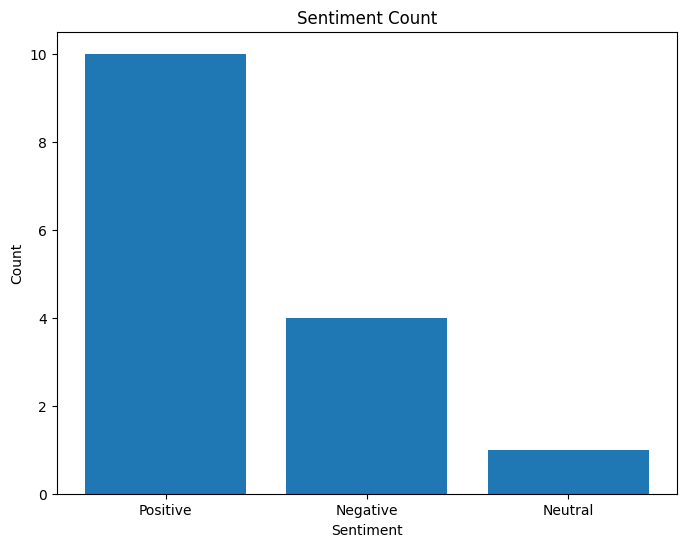

In [20]:
sentiment_counts=df['Sentiment'].value_counts()
plt.figure(figsize=(8,6))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Count')
plt.show()

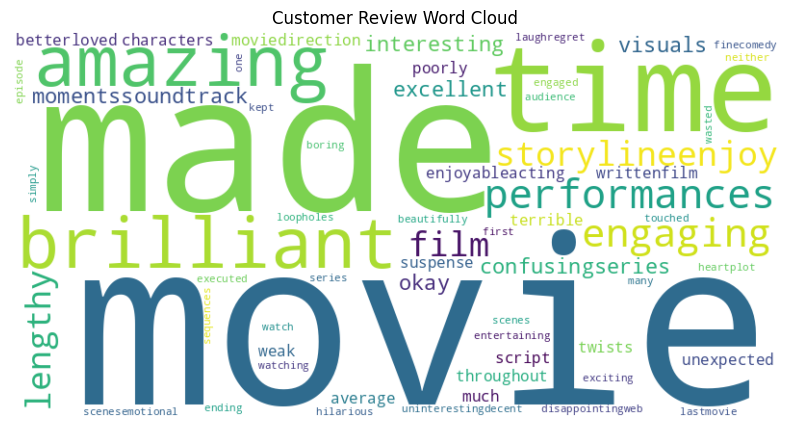

In [21]:
wordcloud=WordCloud(
    width=800,
    height=400,
    background_color='white'
    ).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Customer Review Word Cloud')
plt.show()